In [ ]:
import tkinter as tk
from tkinter import scrolledtext, messagebox
import requests
from bs4 import BeautifulSoup
import webbrowser
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import networkx as nx
import threading


class SearchApp:
    def __init__(self, root):
        self.root = root
        self.root.title("News, Wiki, Image Search, and Data Analysis")
        self.root.geometry("1000x800")

       
        self.df = self.create_sample_data()
        self.products_df = self.create_products_data()

      
        control_frame = tk.LabelFrame(root, text="Controls", font=("Arial", 12), padx=10, pady=10)
        control_frame.pack(pady=10, fill="x")

      
        tk.Label(control_frame, text="Enter Search Query:", font=("Arial", 12)).pack(pady=5)
        self.query_entry = tk.Entry(control_frame, width=50, font=("Arial", 10))
        self.query_entry.pack(pady=5)

       
        button_frame = tk.Frame(control_frame)
        button_frame.pack(pady=5)

      
        tk.Button(button_frame, text="Search Wikinews", command=self.search_wikinews, font=("Arial", 10)).pack(side=tk.LEFT, padx=5)
        tk.Button(button_frame, text="Search Wikipedia", command=self.search_wikipedia, font=("Arial", 10)).pack(side=tk.LEFT, padx=5)
        tk.Button(button_frame, text="Search Images", command=self.search_images, font=("Arial", 10)).pack(side=tk.LEFT, padx=5)

        
        analysis_frame = tk.LabelFrame(root, text="Data Analysis", font=("Arial", 12), padx=10, pady=10)
        analysis_frame.pack(pady=10, fill="x")

        tk.Button(analysis_frame, text="Show Statistics", command=self.show_statistics, font=("Arial", 10)).pack(side=tk.LEFT, padx=5)
        tk.Button(analysis_frame, text="Show Price Distribution", command=self.show_price_distribution, font=("Arial", 10)).pack(side=tk.LEFT, padx=5)
        tk.Button(analysis_frame, text="Show Rating Distribution", command=self.show_rating_distribution, font=("Arial", 10)).pack(side=tk.LEFT, padx=5)
        tk.Button(analysis_frame, text="Show Product Heatmap", command=self.show_product_heatmap, font=("Arial", 10)).pack(side=tk.LEFT, padx=5)

        
        networkx_frame = tk.LabelFrame(root, text="NetworkX Graphs", font=("Arial", 12), padx=10, pady=10)
        networkx_frame.pack(pady=10, fill="x")

        tk.Button(networkx_frame, text="Basic Graph", command=self.show_networkx_basic, font=("Arial", 10)).pack(side=tk.LEFT, padx=5)
        tk.Button(networkx_frame, text="Directed Graph", command=self.show_networkx_directed, font=("Arial", 10)).pack(side=tk.LEFT, padx=5)
        tk.Button(networkx_frame, text="Cycle Graph", command=self.show_networkx_cycle, font=("Arial", 10)).pack(side=tk.LEFT, padx=5)
        tk.Button(networkx_frame, text="Complete Graph", command=self.show_networkx_complete, font=("Arial", 10)).pack(side=tk.LEFT, padx=5)
        tk.Button(networkx_frame, text="Star Graph", command=self.show_networkx_star, font=("Arial", 10)).pack(side=tk.LEFT, padx=5)
        tk.Button(networkx_frame, text="Random Graph", command=self.show_networkx_random, font=("Arial", 10)).pack(side=tk.LEFT, padx=5)
        tk.Button(networkx_frame, text="iPhone Price Network", command=self.show_iphone_price_network, font=("Arial", 10)).pack(side=tk.LEFT, padx=5)

      
        self.result_text = scrolledtext.ScrolledText(root, width=70, height=15, font=("Arial", 10))
        self.result_text.pack(pady=10, padx=10, fill="both")

        
        self.button_frame = tk.Frame(root)
        self.button_frame.pack(pady=5)

        
        self.graph_frame = tk.Frame(root)
        self.graph_frame.pack(pady=5, fill="both", expand=True)

        
        self.loading_label = None

    def create_sample_data(self):
        np.random.seed(42)
        data = {
            'price': np.random.normal(1000, 200, 1000),
            'rating': np.random.uniform(1, 5, 1000),
            'review_count': np.random.randint(10, 500, 1000)
        }
        df = pd.DataFrame(data)
        df = df.dropna(subset=['price', 'rating', 'review_count'])
        df['price'] = df['price'].apply(pd.to_numeric, errors='coerce')
        df['rating'] = df['rating'].apply(pd.to_numeric, errors='coerce')
        df['review_count'] = df['review_count'].apply(pd.to_numeric, errors='coerce')
        df['rating_category'] = pd.cut(df['rating'], bins=[0, 2, 3, 4, 5], labels=['Poor', 'Fair', 'Good', 'Excellent'])
        return df

    def create_products_data(self):
        regions = ["Asia", "Europe", "North America"]
        products = ["iPhone 12", "iPhone 13", "iPhone 14", "iPhone 15", "iPhone 15 Pro"]
        data = {
            "Region": [],
            "Product": [],
            "Price": []
        }
        
        for region in regions:
            for product in products:
                if region == "Asia":
                    if product == "iPhone 12": data["Price"].append(710.0)
                    elif product == "iPhone 13": data["Price"].append(843.0)
                    elif product == "iPhone 14": data["Price"].append(968.0)
                    elif product == "iPhone 15": data["Price"].append(1010.0)
                    elif product == "iPhone 15 Pro": data["Price"].append(1210.0)
                elif region == "Europe":
                    if product == "iPhone 12": data["Price"].append(720.0)
                    elif product == "iPhone 13": data["Price"].append(820.0)
                    elif product == "iPhone 14": data["Price"].append(960.0)
                    elif product == "iPhone 15": data["Price"].append(1020.0)
                    elif product == "iPhone 15 Pro": data["Price"].append(1220.0)
                elif region == "North America":
                    if product == "iPhone 12": data["Price"].append(699.0)
                    elif product == "iPhone 13": data["Price"].append(799.0)
                    elif product == "iPhone 14": data["Price"].append(898.0)
                    elif product == "iPhone 15": data["Price"].append(999.0)
                    elif product == "iPhone 15 Pro": data["Price"].append(1199.0)
                data["Region"].append(region)
                data["Product"].append(product)

        products_df = pd.DataFrame(data)
        return products_df

    def show_loading(self):
        if not self.loading_label:
            self.loading_label = tk.Label(self.root, text="Loading, please wait...", font=("Arial", 10))
            self.loading_label.pack(pady=5)
        self.root.update()

    def hide_loading(self):
        if self.loading_label:
            self.loading_label.destroy()
            self.loading_label = None

    def search_wikinews(self):
        query = self.query_entry.get().strip()
        if not query:
            messagebox.showwarning("Input Error", "Please enter a search query.")
            return

        self.result_text.delete(1.0, tk.END)
        self.result_text.insert(tk.END, f"Searching Wikinews for '{query}'...\n\n")
        self.show_loading()

        def perform_search():
            try:
                search_url = f"https://en.wikinews.org/w/index.php?search={query}&title=Special%3ASearch&profile=default&fulltext=1"
                response = requests.get(search_url, headers={"User-Agent": "Mozilla/5.0"}, timeout=10)
                if response.status_code == 200:
                    soup = BeautifulSoup(response.text, "html.parser")
                    news = soup.select("div.mw-search-result-heading a")
                    self.result_text.delete(1.0, tk.END)
                    if news:
                        self.result_text.insert(tk.END, f"Wikinews Search Results for '{query}':\n")
                        for item in news:
                            title = item.text
                            link = "https://en.wikinews.org" + item["href"]
                            self.result_text.insert(tk.END, f"- {title}: {link}\n")
                    else:
                        self.result_text.insert(tk.END, f"No news articles found for '{query}'.\n")
                else:
                    self.result_text.insert(tk.END, f"Failed to fetch the page (Status Code: {response.status_code}).\n")
            except requests.RequestException as e:
                self.result_text.insert(tk.END, f"Error during Wikinews search: {str(e)}\n")
            finally:
                self.hide_loading()

        threading.Thread(target=perform_search, daemon=True).start()

    def search_wikipedia(self):
        query = self.query_entry.get().strip()
        if not query:
            messagebox.showwarning("Input Error", "Please enter a search query.")
            return

        self.result_text.delete(1.0, tk.END)
        self.result_text.insert(tk.END, f"Searching Wikipedia for '{query}'...\n\n")
        self.show_loading()

        def perform_search():
            try:
                url = f"https://en.wikipedia.org/w/api.php?action=query&format=json&list=search&srsearch={query}&srlimit=50"
                response = requests.get(url, timeout=10)
                response.raise_for_status()
                data = response.json()
                self.result_text.delete(1.0, tk.END)
                results = data["query"]["search"]
                if results:
                    self.result_text.insert(tk.END, "Wikipedia Results:\n")
                    for item in results:
                        title = item["title"]
                        snippet = item["snippet"].replace("<span class=\"searchmatch\">", "").replace("</span>", "")
                        self.result_text.insert(tk.END, f"{title} - {snippet}\n")
                else:
                    self.result_text.insert(tk.END, f"No Wikipedia articles found for '{query}'.\n")
            except requests.RequestException as e:
                self.result_text.insert(tk.END, f"Error during Wikipedia search: {str(e)}\n")
            finally:
                self.hide_loading()

        threading.Thread(target=perform_search, daemon=True).start()

    def search_images(self):
        for widget in self.button_frame.winfo_children():
            widget.destroy()

        query = self.query_entry.get().strip()
        if not query:
            messagebox.showwarning("Input Error", "Please enter a search query.")
            return

        self.result_text.delete(1.0, tk.END)
        self.result_text.insert(tk.END, f"Searching Wikipedia for images related to '{query}'...\n\n")
        self.show_loading()

        def perform_search():
            chrome_options = Options()
            chrome_options.add_argument("no-sandbox")
            chrome_options.add_argument("disable-gpu")
            chrome_options.add_argument("user-agent=Mozilla/5.0")
            service = Service(ChromeDriverManager().install())
            driver = webdriver.Chrome(service=service, options=chrome_options)

            try:
                url = f"https://en.wikipedia.org/w/index.php?search={query}&fulltext=1"
                driver.get(url)
                time.sleep(5)

                current_url = driver.current_url
                if "search=" not in current_url:
                    self.result_text.insert(tk.END, "Redirected to article page. Extracting images...\n")
                else:
                    try:
                        results = driver.find_elements(By.CSS_SELECTOR, "div.mw-search-result-heading a")
                        if results:
                            results[0].click()
                            time.sleep(5)
                        else:
                            self.result_text.insert(tk.END, "No search results found.\n")
                            return
                    except Exception as e:
                        self.result_text.insert(tk.END, f"Error accessing search results: {str(e)}\n")
                        return

                images = driver.find_elements(By.TAG_NAME, "img")
                image_urls = []
                for img in images:
                    src = img.get_attribute("src")
                    if src and "http" in src:
                        image_urls.append(src)
                    elif src and not src.startswith("http"):
                        src = "https://en.wikipedia.org" + src
                        image_urls.append(src)

                self.result_text.delete(1.0, tk.END)
                if image_urls:
                    self.result_text.insert(tk.END, f"Image Results for '{query}':\n")
                    for i, url in enumerate(image_urls[:5], 1):
                        self.result_text.insert(tk.END, f"Image {i}: {url}\n")
                        btn = tk.Button(self.button_frame, text=f"Open Image {i}",
                                        command=lambda u=url: webbrowser.open(u), font=("Arial", 10))
                        btn.pack(side=tk.LEFT, padx=5)
                else:
                    self.result_text.insert(tk.END, "No images found.\n")

            except Exception as e:
                self.result_text.insert(tk.END, f"Error during image search: {str(e)}\n")
            finally:
                driver.quit()
                self.hide_loading()

        threading.Thread(target=perform_search, daemon=True).start()

    def show_statistics(self):
        price_mean = self.df['price'].mean()
        price_median = self.df['price'].median()
        rating_mean = self.df['rating'].mean()
        rating_median = self.df['rating'].median()

        statistics = {
            "Price Mean": price_mean,
            "Price Median": price_median,
            "Rating Mean": rating_mean,
            "Rating Median": rating_median
        }

        self.result_text.delete(1.0, tk.END)
        self.result_text.insert(tk.END, "iPhone Statistics:\n\n")
        for key, value in statistics.items():
            self.result_text.insert(tk.END, f"{key}: {value:.2f}\n")

    def show_price_distribution(self):
        for widget in self.graph_frame.winfo_children():
            widget.destroy()
        fig, ax = plt.subplots(figsize=(8, 5))
        sns.histplot(self.df['price'], bins=30, kde=True, color='blue', ax=ax)
        ax.set_title('Distribution of iPhone Prices')
        ax.set_xlabel('Price')
        ax.set_ylabel('Frequency')
        plt.tight_layout()
        canvas = FigureCanvasTkAgg(fig, master=self.graph_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(expand=True, fill=tk.BOTH)

    def show_rating_distribution(self):
        for widget in self.graph_frame.winfo_children():
            widget.destroy()
        fig, ax = plt.subplots(figsize=(8, 5))
        sns.histplot(self.df['rating'], bins=20, kde=True, color='green', ax=ax)
        ax.set_title('Distribution of iPhone Ratings')
        ax.set_xlabel('Rating')
        ax.set_ylabel('Frequency')
        plt.tight_layout()
        canvas = FigureCanvasTkAgg(fig, master=self.graph_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(expand=True, fill=tk.BOTH)

    def show_product_heatmap(self):
        for widget in self.graph_frame.winfo_children():
            widget.destroy()
        pivot_table = self.products_df.pivot_table(index="Region", columns="Product", values="Price", aggfunc="mean")
        fig, ax = plt.subplots(figsize=(10, 6))
        heatmap_data = pivot_table.values
        im = ax.imshow(heatmap_data, cmap="hot", interpolation="nearest", vmin=700, vmax=1220)
        fig.colorbar(im, label="Price")
        ax.set_xticks(np.arange(len(pivot_table.columns)))
        ax.set_xticklabels(pivot_table.columns, rotation=45, fontsize=10)
        ax.set_yticks(np.arange(len(pivot_table.index)))
        ax.set_yticklabels(pivot_table.index, fontsize=10)
        for i in range(len(pivot_table.index)):
            for j in range(len(pivot_table.columns)):
                ax.text(j, i, f"{heatmap_data[i, j]:.1f}", ha="center", va="center", color="purple", fontsize=8)
        ax.set_title("Heatmap of iPhone Prices by Region")
        ax.set_xlabel("Product")
        ax.set_ylabel("Region")
        plt.tight_layout(pad=2.0)
        canvas = FigureCanvasTkAgg(fig, master=self.graph_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(expand=True, fill=tk.BOTH)

   
    def show_networkx_basic(self):
        for widget in self.graph_frame.winfo_children():
            widget.destroy()
        G = nx.Graph()
        G.add_nodes_from([1, 2, 3, 4, 5])
        G.add_edges_from([(1, 2), (1, 3), (2, 4), (3, 4), (4, 5)])
        fig, ax = plt.subplots(figsize=(8, 5))
        nx.draw(G, with_labels=True, node_color="skyblue", node_size=500, font_size=12, font_weight="bold", edge_color="gray", ax=ax)
        ax.set_title('Basic NetworkX Graph')
        plt.tight_layout()
        canvas = FigureCanvasTkAgg(fig, master=self.graph_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(expand=True, fill=tk.BOTH)

    def show_networkx_directed(self):
        for widget in self.graph_frame.winfo_children():
            widget.destroy()
        G = nx.DiGraph()
        G.add_nodes_from([1, 2, 3, 4, 5])
        G.add_edges_from([(1, 2), (2, 3), (3, 1), (4, 3), (5, 4)])
        fig, ax = plt.subplots(figsize=(8, 5))
        nx.draw(G, with_labels=True, node_color="lightgreen", node_size=500, font_size=12, font_weight="bold", edge_color="blue", arrows=True, ax=ax)
        ax.set_title('Directed NetworkX Graph')
        plt.tight_layout()
        canvas = FigureCanvasTkAgg(fig, master=self.graph_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(expand=True, fill=tk.BOTH)

    def show_networkx_cycle(self):
        for widget in self.graph_frame.winfo_children():
            widget.destroy()
        G = nx.cycle_graph(6)
        fig, ax = plt.subplots(figsize=(8, 5))
        nx.draw(G, with_labels=True, node_color="lightcoral", node_size=500, font_size=12, font_weight="bold", edge_color="purple", ax=ax)
        ax.set_title('Cycle NetworkX Graph')
        plt.tight_layout()
        canvas = FigureCanvasTkAgg(fig, master=self.graph_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(expand=True, fill=tk.BOTH)

    def show_networkx_complete(self):
        for widget in self.graph_frame.winfo_children():
            widget.destroy()
        G = nx.complete_graph(5)
        fig, ax = plt.subplots(figsize=(8, 5))
        nx.draw(G, with_labels=True, node_color="gold", node_size=500, font_size=12, font_weight="bold", edge_color="green", ax=ax)
        ax.set_title('Complete NetworkX Graph')
        plt.tight_layout()
        canvas = FigureCanvasTkAgg(fig, master=self.graph_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(expand=True, fill=tk.BOTH)

    def show_networkx_star(self):
        for widget in self.graph_frame.winfo_children():
            widget.destroy()
        G = nx.star_graph(5)
        fig, ax = plt.subplots(figsize=(8, 5))
        nx.draw(G, with_labels=True, node_color="lightpink", node_size=500, font_size=12, font_weight="bold", edge_color="orange", ax=ax)
        ax.set_title('Star NetworkX Graph')
        plt.tight_layout()
        canvas = FigureCanvasTkAgg(fig, master=self.graph_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(expand=True, fill=tk.BOTH)

    def show_networkx_random(self):
        for widget in self.graph_frame.winfo_children():
            widget.destroy()
        G = nx.erdos_renyi_graph(10, 0.3)
        fig, ax = plt.subplots(figsize=(8, 5))
        nx.draw(G, with_labels=True, node_color="lightyellow", node_size=500, font_size=12, font_weight="bold", edge_color="red", ax=ax)
        ax.set_title('Random NetworkX Graph')
        plt.tight_layout()
        canvas = FigureCanvasTkAgg(fig, master=self.graph_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(expand=True, fill=tk.BOTH)

    def make_network(self):
        G = nx.Graph()
       
        unique_products = self.products_df["Product"].unique()
        prices = {}
        for product in unique_products:
            price = self.products_df[self.products_df["Product"] == product]["Price"].iloc[0] 
            prices[product] = price
            G.add_node(product, price=price)
        
        models = list(prices.keys())
        for i in range(len(models)):
            for j in range(i + 1, len(models)):
                diff = abs(prices[models[i]] - prices[models[j]])
                if diff <= 300:  
                    G.add_edge(models[i], models[j], weight=diff)
        return G

    def show_iphone_price_network(self):
        for widget in self.graph_frame.winfo_children():
            widget.destroy()
        G = self.make_network()
        pos = nx.spring_layout(G, seed=42)
        labels = {node: f"{node}\n${G.nodes[node]['price']}" for node in G.nodes}
        fig, ax = plt.subplots(figsize=(8, 5))
        nx.draw(G, pos, with_labels=True, labels=labels, node_color="skyblue", edge_color="gray", node_size=1500, font_size=10, ax=ax)
        edge_labels = {(u, v): f"{d['weight']}" for u, v, d in G.edges(data=True)}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
        ax.set_title("iPhone Price Network")
        plt.tight_layout()
        canvas = FigureCanvasTkAgg(fig, master=self.graph_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(expand=True, fill=tk.BOTH)

if __name__ == "__main__":
    root = tk.Tk()
    app = SearchApp(root)
    root.mainloop()

C:\Users\beshoy nader\AppData\Local\Temp\ipykernel_27556\2631389262.py:385: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(8, 5))


In [2]:
#Web scrraping
import requests
from bs4 import BeautifulSoup

search_query = "iPhone"
search_url = f"https://en.wikinews.org/w/index.php?search={search_query}&title=Special%3ASearch&profile=default&fulltext=1"

response = requests.get(search_url, headers={"User-Agent": "Mozilla/5.0"})

if response.status_code == 200:
    soup = BeautifulSoup(response.text, "html.parser")
    news = soup.select("div.mw-search-result-heading a")

    if news:
        print(f"Wikinews Search Results for '{search_query}':")
        for item in news:
            title = item.text
            link = "https://en.wikinews.org" + item["href"]
            print(f"- {title}: {link}")
    else:
        print(f"No news articles found for '{search_query}'.")
else:
    print("Failed to fetch the page")

Wikinews Search Results for 'iPhone':
- Nokia Inc. announces plans for iPhone rival: https://en.wikinews.org/wiki/Nokia_Inc._announces_plans_for_iPhone_rival
- Apple unveils iPhone 4, iOS 4 at Worldwide Developers Conference 2010: https://en.wikinews.org/wiki/Apple_unveils_iPhone_4,_iOS_4_at_Worldwide_Developers_Conference_2010
- Apple launches new, faster iPhone: https://en.wikinews.org/wiki/Apple_launches_new,_faster_iPhone
- Apple concerned with iPhone icons' alleged misuse: https://en.wikinews.org/wiki/Apple_concerned_with_iPhone_icons%27_alleged_misuse
- Cisco sues Apple for iPhone trademark: https://en.wikinews.org/wiki/Cisco_sues_Apple_for_iPhone_trademark
- Fans worldwide queue for new iPhone: https://en.wikinews.org/wiki/Fans_worldwide_queue_for_new_iPhone
- Release of 'Verizon iPhone' set for early February: https://en.wikinews.org/wiki/Release_of_%27Verizon_iPhone%27_set_for_early_February
- Apple swamped by iPhone 4 pre-orders: https://en.wikinews.org/wiki/Apple_swamped_by_

In [3]:
#API
import requests

query = "iphone"
url = "https://en.wikipedia.org/w/api.php?action=query&format=json&list=search&srsearch=" + query + "&srlimit=50"

response = requests.get(url)
data = response.json()

results = data["query"]["search"]

print("Wikipedia results:")
for item in results:
    print(item["title"] + " - " + item["snippet"])

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
#selenium
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup
import time

chrome_options = Options()
chrome_options.add_argument("no-sandbox")
chrome_options.add_argument("disable-gpu")

service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=chrome_options)

query = "iphones"
url = f"https://en.wikipedia.org/w/index.php?search={query}"
driver.get(url)

time.sleep(10)

soup = BeautifulSoup(driver.page_source, "html.parser")
items = soup.find_all("div", class_="mw-search-result")

print(" All Wikipedia Search Results")
for item in items:
    title = item.find("a")
    description = item.find("div", class_="searchresult")
    if title:
        desc_text = description.text.strip() if description else "No description"
        print(f" {title.text} - {desc_text}")

driver.quit()

 All Wikipedia Search Results


<Response [200]>
Wikinews Headlines about iPhone:
 iPhone 12
 The iPhone 12 and iPhone 12 Mini (stylized and marketed as iPhone 12 mini) are smartphones developed...
 Image: https://upload.wikimedia.org/wikipedia/commons/thumb/3/34/IPhone_12_Blue.svg/500px-IPhone_12_Blue.svg.png
 https://en.wikipedia.org/wiki/IPhone_12
🧹 Cleaned

 iPhone 13
 The iPhone 13 and iPhone 13 Mini (stylized as iPhone 13 mini) are smartphones developed and marketed...
 Image: https://upload.wikimedia.org/wikipedia/commons/thumb/0/0c/IPhone_13_vector.svg/500px-IPhone_13_vector.svg.png
 https://en.wikipedia.org/wiki/IPhone_13
🧹 Cleaned

 iPhone 14
 The iPhone 14 and iPhone 14 Plus are smartphones developed and marketed by Apple Inc. They are the s...
 Image: https://upload.wikimedia.org/wikipedia/commons/thumb/6/61/IPhone_14_vector.svg/500px-IPhone_14_vector.svg.png
 https://en.wikipedia.org/wiki/IPhone_14
🧹 Cleaned

 iPhone 15
 The iPhone 15 and iPhone 15 Plus are smartphones developed and marketed by Apple. Th

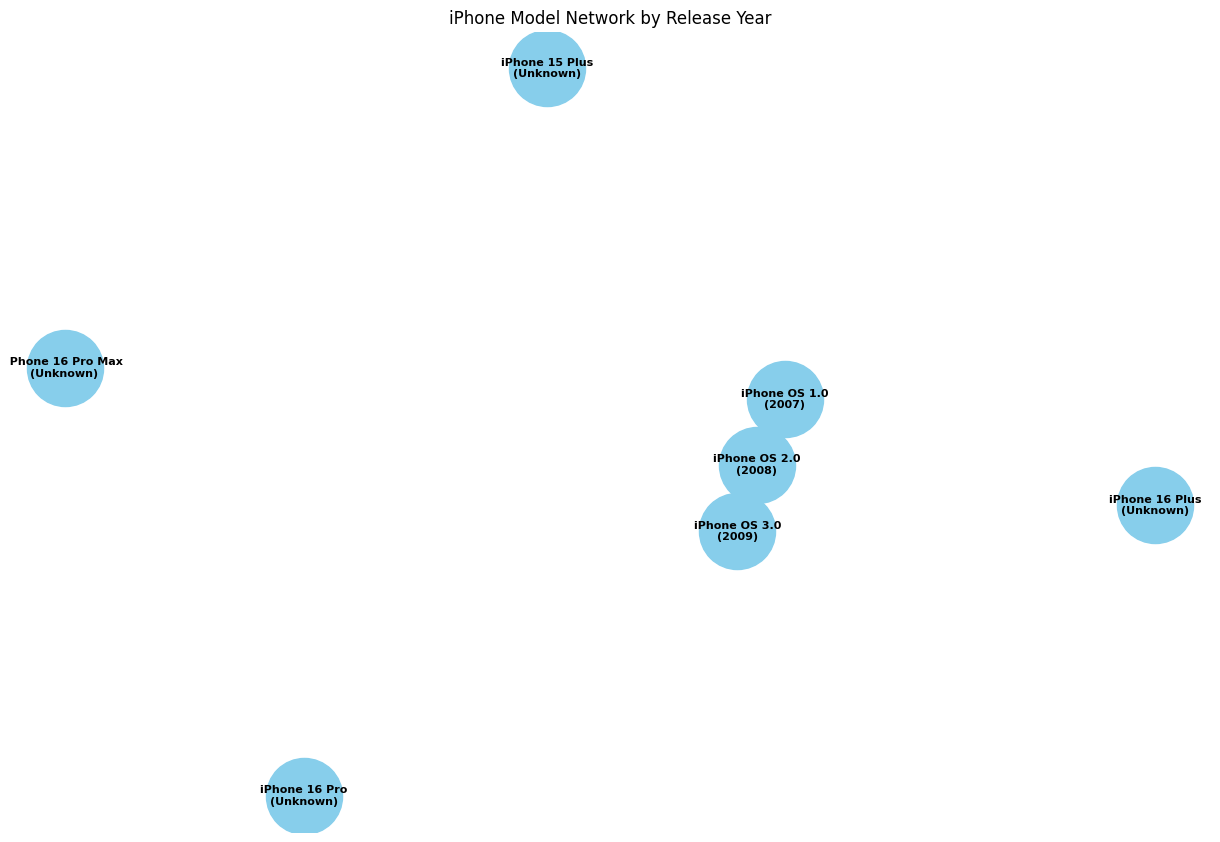

In [ ]:
# network x and cleaning for web scraping
import networkx as nx
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup
import re
from requests.exceptions import RequestException

url = "https://en.wikinews.org/wiki/Main_Page"
try:
    response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=10)
    response.raise_for_status()
    print(response)
except RequestException as e:
    print(f"Error fetching Wikinews: {e}")

soup = BeautifulSoup(response.text, "html.parser")
news = soup.select("div.mw-parser-output ul li a")
print("Wikinews Headlines about iPhone:")
iphone_headlines = [headline.text.strip() for headline in news if "iPhone" in headline.text]
for headline in iphone_headlines:
    print(f"- {headline}")

def iphone(model):
    url = "https://en.wikipedia.org/w/api.php"
    params = {
        "action": "query", "format": "json", "titles": model,
        "prop": "extracts|pageimages|info", "exintro": True, "explaintext": True,
        "pithumbsize": 500, "inprop": "url"
    }
    try:
        res = requests.get(url, params=params, timeout=10)
        res.raise_for_status()
        data = res.json()
        page = list(data.get("query", {}).get("pages", {}).values())[0]
        if "missing" in page:
            return {
                "name": model,
                "desc": "Page not found.",
                "img": "No image.",
                "url": "No link.",
                "status": "Failed"
            }
        return {
            "name": model,
            "desc": page.get("extract", "No description.")[:100] + "...",
            "img": page.get("thumbnail", {}).get("source", "No image."),
            "url": page.get("fullurl", "No link."),
            "status": "Cleaned"
        }
    except (RequestException, KeyError, IndexError) as e:
        print(f"Error fetching data for {model}: {e}")
        return {
            "name": model,
            "desc": "Error fetching description.",
            "img": "No image.",
            "url": "No link.",
            "status": "Failed"
        }

models = ["iPhone 12", "iPhone 13", "iPhone 14", "iPhone 15"]
for data in map(iphone, models):
    print(f" {data['name']}\n {data['desc']}\n Image: {data['img']}\n {data['url']}\n🧹 {data['status']}\n")

def get_iphone_models():
    url = "https://en.wikipedia.org/wiki/IPhone"
    try:
        res = requests.get(url, timeout=10)
        res.raise_for_status()
        soup = BeautifulSoup(res.text, "html.parser")
        iphones = []
        for table in soup.find_all("table", class_="wikitable"):
            for row in table.find_all("tr")[1:]:
                cells = row.find_all("td")
                if cells and "iPhone" in cells[0].text:
                    model = re.sub(r"\[\w+\]", "", cells[0].text.strip())
                    year = cells[1].text.strip() if len(cells) > 1 else "Unknown"
                    year = re.search(r"\d{4}", year)
                    year = year.group() if year else "Unknown"
                    iphones.append({"model": model, "year": year})
        return iphones
    except RequestException as e:
        print(f"Error fetching iPhone models: {e}")
        return []

def build_network(iphones):
    G = nx.Graph()
    for iphone in iphones:
        G.add_node(iphone["model"], year=iphone["year"])
    for i in range(len(iphones)):
        for j in range(i + 1, len(iphones)):
            year_i = iphones[i]["year"]
            year_j = iphones[j]["year"]
            if year_i != "Unknown" and year_j != "Unknown":
                if abs(int(year_i) - int(year_j)) <= 1:
                    G.add_edge(iphones[i]["model"], iphones[j]["model"])
    return G

def plot_network(G):
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, seed=42)
    node_labels = {node: f"{node}\n({G.nodes[node]['year']})" for node in G.nodes}
    nx.draw(
        G, pos, with_labels=True, labels=node_labels,
        node_color="skyblue", edge_color="gray",
        node_size=3000, font_size=8, font_weight="bold"
    )
    plt.title("iPhone Model Network by Release Year")
    plt.show()

iphones = get_iphone_models()
if iphones:
    G = build_network(iphones)
    plot_network(G)
else:
    print(" No iPhone data found.")

https://upload.wikimedia.org/wikipedia/en/4/4a/Commons-logo.svg
https://upload.wikimedia.org/wikipedia/commons/6/6d/First_iPhone_Macworld_2007_DSCF1286.agr.jpg
https://upload.wikimedia.org/wikipedia/commons/6/63/IOS_wordmark_%282017%29.svg
https://upload.wikimedia.org/wikipedia/commons/a/a2/IPhone_13_Pro_camera_lens_group.jpg
https://upload.wikimedia.org/wikipedia/commons/d/d2/IPhone_16_Pro_Vector.svg
https://upload.wikimedia.org/wikipedia/commons/a/a1/IPhone_3G_Availability.svg
https://upload.wikimedia.org/wikipedia/commons/7/7f/IPhone_6s_-_opened-92987.jpg
https://upload.wikimedia.org/wikipedia/en/8/8a/OOjs_UI_icon_edit-ltr-progressive.svg
https://upload.wikimedia.org/wikipedia/en/1/1b/Semi-protection-shackle.svg
https://upload.wikimedia.org/wikipedia/commons/4/49/Size_comparison_of_iPhone_5C_5S_4S.jpg
News about iPhone:
- IPhone: accessibility features. Up to the iPhone 8 and 8 Plus, iPhones had a single button on the front panel, with the iPhone 5s and later integrating a Touch
  R

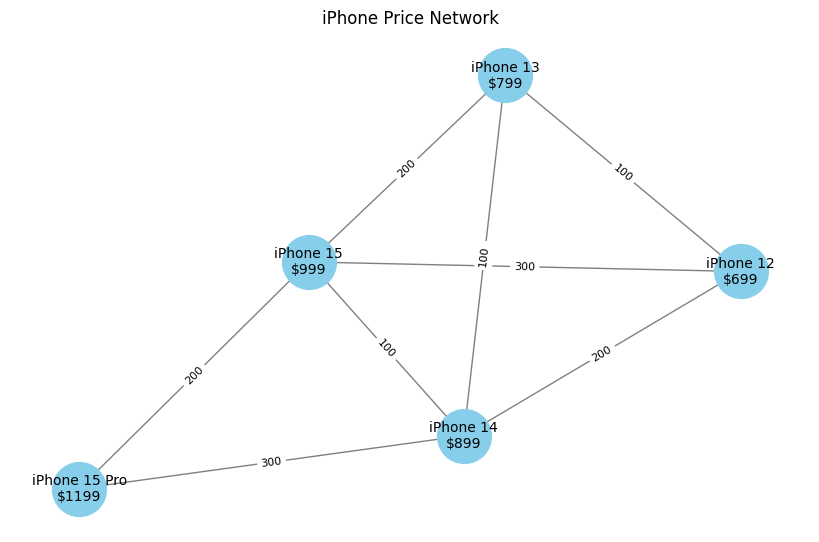

 IPhone
 accessibility features. Up to the iPhone 8 and 8 Plus, iPhones had a single button on the front panel, with the iPhone 5s and later integrating a Touch
 https://en.wikipedia.org/?curid=8841749

 History of the iPhone
 of Mexico upheld that iFone is the rightful owner and held that Apple iPhone is a trademark violation. In Brazil, the brand IPHONE was registered in 2000
 https://en.wikipedia.org/?curid=13678080

 List of iPhone models
 The iPhone, developed by Apple Inc., is a line of smartphones that combine a mobile phone, digital camera, personal computer, and music player into one
 https://en.wikipedia.org/?curid=23241092

 IPhone (1st generation)
 of the iPhone began in 2005 and continued in secrecy until its public unveiling at Macworld 2007. The device broke with prevailing mobile phone designs
 https://en.wikipedia.org/?curid=27761763

 IOS
 iOS (formerly iPhone OS) is a mobile operating system developed by Apple exclusively for its mobile devices. It was unveiled in Ja

In [ ]:
# network x and cleaning for API
import networkx as nx
import matplotlib.pyplot as plt
import requests
import re
from requests.exceptions import RequestException

def get_images(topic="iPhone"):
    url = "https://en.wikipedia.org/w/api.php"
    def query(params):
        try:
            res = requests.get(url, params=params, timeout=10)
            res.raise_for_status()
            return res.json().get("query", {}).get("pages", {})
        except (RequestException, ValueError) as e:
            print(f"Error in query for {params.get('titles', 'unknown')}: {e}")
            return {}
    images = [img["title"] for p in query({"action": "query", "format": "json", "titles": topic, "prop": "images"}).values() for img in p.get("images", [])]
    return [p["imageinfo"][0]["url"] for name in images for p in query({"action": "query", "format": "json", "titles": name, "prop": "imageinfo", "iiprop": "url"}).values() if "imageinfo" in p]

for link in get_images():
    print(link)

def fetch_news(topic="iPhone"):
    url = f"https://en.wikipedia.org/w/api.php"
    try:
        res = requests.get(url, params={"action": "query", "format": "json", "list": "search", "srsearch": topic, "srlimit": 10}, timeout=10)
        res.raise_for_status()
        results = res.json().get("query", {}).get("search", [])
        print(f"News about {topic}:")
        for item in results:
            title = item["title"]
            snippet = re.sub(r"<[^>]+>", "", item["snippet"])
            link = f"https://en.wikipedia.org/?curid={item['pageid']}"
            print(f"- {title}: {snippet}")
            print(f"  Read more: {link}\n")
    except (RequestException, ValueError) as e:
        print(f"Error fetching news: {e}")

fetch_news()

def fetch_iphone_info(models):
    url = "https://en.wikipedia.org/w/api.php"
    iphones = {}
    for model in models:
        try:
            res = requests.get(url, params={
                "action": "query", "format": "json", "titles": model,
                "prop": "extracts|pageimages", "exintro": True, "explaintext": True, "pithumbsize": 500
            }, timeout=10)
            res.raise_for_status()
            page = next(iter(res.json().get("query", {}).get("pages", {}).values()), {})
            if "missing" in page:
                iphones[model] = {"desc": "Page not found.", "img": "No image."}
            else:
                iphones[model] = {
                    "desc": page.get("extract", "No info.")[:100] + "...",
                    "img": page.get("thumbnail", {}).get("source", "No image.")
                }
        except (RequestException, ValueError) as e:
            print(f"Error fetching info for {model}: {e}")
            iphones[model] = {"desc": "Error fetching info.", "img": "No image."}
    return iphones

models = ["iPhone 12", "iPhone 13", "iPhone 14", "iPhone 15"]
iphones_info = fetch_iphone_info(models)
for name, data in iphones_info.items():
    print(f" {name}\n {data['desc']}\n {data['img']}\n")

iphones = {
    "iPhone 12": 699,
    "iPhone 13": 799,
    "iPhone 14": 899,
    "iPhone 15": 999,
    "iPhone 15 Pro": 1199
}

def make_network():
    G = nx.Graph()
    for model, price in iphones.items():
        G.add_node(model, price=price)
    models = list(iphones.keys())
    for i in range(len(models)):
        for j in range(i + 1, len(models)):
            diff = abs(iphones[models[i]] - iphones[models[j]])
            if diff <= 300:
                G.add_edge(models[i], models[j], weight=diff)
    return G

def draw_network(G):
    pos = nx.spring_layout(G, seed=42)
    labels = {node: f"{node}\n${G.nodes[node]['price']}" for node in G.nodes}
    plt.figure(figsize=(8, 5))
    nx.draw(G, pos, with_labels=True, labels=labels, node_color="skyblue", edge_color="gray", node_size=1500, font_size=10)
    edge_labels = {(u, v): f"{d['weight']}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    plt.title("iPhone Price Network")
    plt.show()

G = make_network()
draw_network(G)

def fetch_news_cleaned():
    url = "https://en.wikipedia.org/w/api.php"
    try:
        res = requests.get(url, params={"action": "query", "format": "json", "list": "search", "srsearch": "iPhone", "srlimit": 10}, timeout=10)
        res.raise_for_status()
        data = res.json().get("query", {}).get("search", [])
        news = [{"title": item["title"], "description": re.sub(r"<[^>]+>", "", item["snippet"]), "link": f"https://en.wikipedia.org/?curid={item['pageid']}"} for item in data]
        for item in news:
            print(f" {item['title']}\n {item['description']}\n {item['link']}\n")
    except (RequestException, ValueError) as e:
        print(f"Error fetching cleaned news: {e}")

fetch_news_cleaned()

def fetch_images(topic="iPhone"):
    url = "https://en.wikipedia.org/w/api.php"
    def get_pages(params):
        try:
            res = requests.get(url, params=params, timeout=10)
            res.raise_for_status()
            return res.json().get("query", {}).get("pages", {})
        except (RequestException, ValueError) as e:
            print(f"Error fetching images for {params.get('titles', 'unknown')}: {e}")
            return {}
    pages = get_pages({"action": "query", "format": "json", "titles": topic, "prop": "images"})
    images = [img["title"] for page in pages.values() for img in page.get("images", [])]
    return [
        page["imageinfo"][0]["url"]
        for img in images
        for page in get_pages({"action": "query", "format": "json", "titles": img, "prop": "imageinfo", "iiprop": "url"}).values()
        if "imageinfo" in page
    ]

for link in fetch_images():
    print(link)

Collected iPhones: []
No iPhones found. Adding sample data for testing.


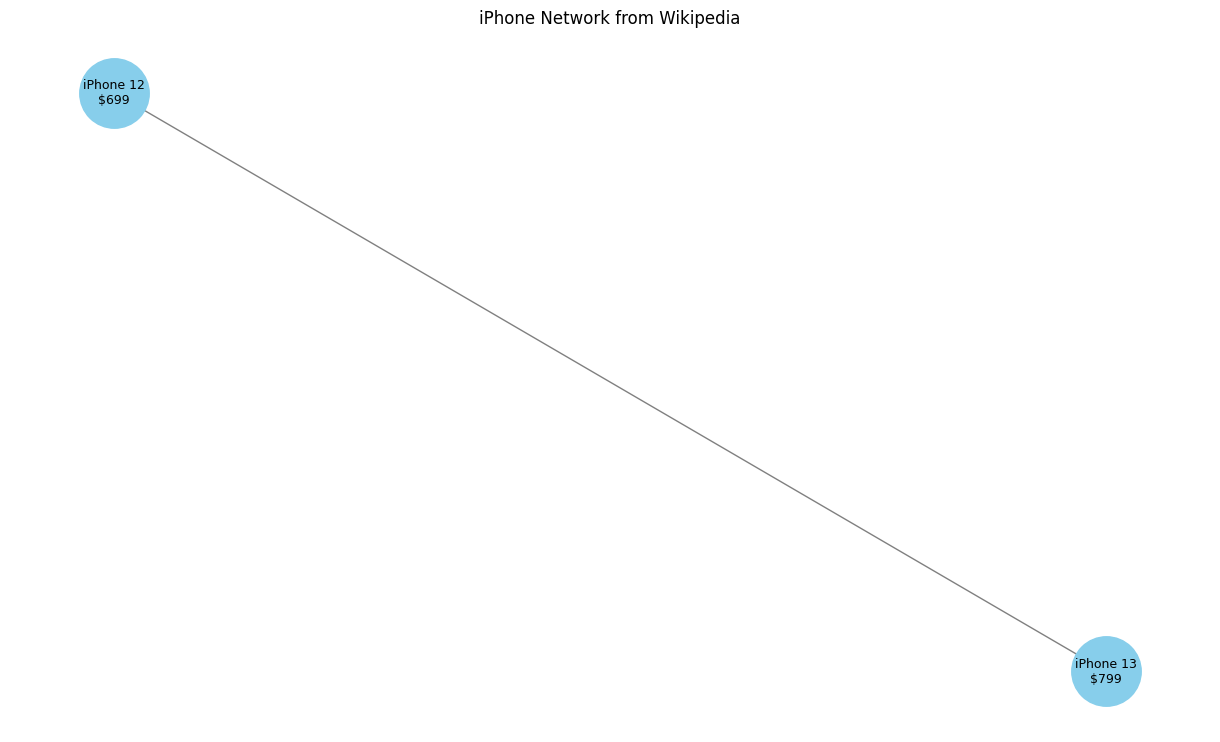

iPhone 12
$699
Sample desc
#

iPhone 13
$799
Sample desc
#


All iPhone Images:
https://upload.wikimedia.org/wikipedia/commons/thumb/d/d2/IPhone_16_Pro_Vector.svg/250px-IPhone_16_Pro_Vector.svg.png
https://upload.wikimedia.org/wikipedia/commons/thumb/a/a1/IPhone_3G_Availability.svg/330px-IPhone_3G_Availability.svg.png
https://upload.wikimedia.org/wikipedia/commons/thumb/6/6d/First_iPhone_Macworld_2007_DSCF1286.agr.jpg/250px-First_iPhone_Macworld_2007_DSCF1286.agr.jpg
https://upload.wikimedia.org/wikipedia/commons/thumb/4/49/Size_comparison_of_iPhone_5C_5S_4S.jpg/250px-Size_comparison_of_iPhone_5C_5S_4S.jpg
https://upload.wikimedia.org/wikipedia/commons/thumb/a/a2/IPhone_13_Pro_camera_lens_group.jpg/250px-IPhone_13_Pro_camera_lens_group.jpg
https://upload.wikimedia.org/wikipedia/commons/thumb/7/7f/IPhone_6s_-_opened-92987.jpg/250px-IPhone_6s_-_opened-92987.jpg


In [ ]:
# network x and cleaning for selenium
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup
import time
import networkx as nx
import matplotlib.pyplot as plt


chrome_options = Options()
chrome_options.add_argument("--headless")
chrome_options.add_argument("--no-sandbox")
chrome_options.add_argument("--disable-gpu")

service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=chrome_options)


query = "iPhones"
search_url = f"https://en.wikipedia.org/w/index.php?search={query}"
driver.get(search_url)
time.sleep(5)

soup = BeautifulSoup(driver.page_source, "html.parser")
items = soup.find_all("div", class_="mw-search-result")

iphones = []
for item in items[:10]:
    title_tag = item.find("a")
    desc_tag = item.find("div", class_="searchresult")

    if title_tag:
        name = title_tag.text.strip()
        link = "https://en.wikipedia.org" + title_tag["href"]
        desc = desc_tag.text.strip() if desc_tag else "No description available."
        iphones.append({"name": name, "link": link, "desc": desc})


for iphone in iphones:
    driver.get(iphone["link"])
    time.sleep(3)
    page_soup = BeautifulSoup(driver.page_source, "html.parser")

    price_text = "Price not listed"
    for row in page_soup.find_all("tr"):
        if "Price" in row.text:
            price_text = row.find("td").text.strip() if row.find("td") else "Unknown"
            break
    iphone["price"] = price_text


driver.get("https://en.wikipedia.org/wiki/IPhone")
time.sleep(5)
soup = BeautifulSoup(driver.page_source, "html.parser")
images = []
for img in soup.find_all("img"):
    img_url = img.get("src", "")
    if "iphone" in img_url.lower():
        images.append(f"https:{img_url}")

driver.quit()


print("Collected iPhones:", iphones)
if not iphones:
    print("No iPhones found. Adding sample data for testing.")
    iphones = [
        {"name": "iPhone 12", "price": "$699", "desc": "Sample desc", "link": "#"},
        {"name": "iPhone 13", "price": "$799", "desc": "Sample desc", "link": "#"}
    ]


def network(iphones):
    G = nx.Graph()
    for iphone in iphones:
        G.add_node(iphone["name"], price=iphone["price"])
    for i in range(len(iphones) - 1):
        G.add_edge(iphones[i]["name"], iphones[i + 1]["name"])
    return G


def draw(G):
    if len(G.nodes) == 0:
        print("No data available to create the network graph.")
        return

    plt.figure(figsize=(12, 7))
    pos = nx.spring_layout(G, seed=42)
    labels = {node: f"{node}\n{G.nodes[node]['price']}" for node in G.nodes}
    nx.draw(G, pos, with_labels=True, labels=labels, node_color="skyblue", edge_color="gray", node_size=2500, font_size=9)
    plt.title("iPhone Network from Wikipedia")
    plt.show()


G = network(iphones)
draw(G)


for iphone in iphones:
    print(f"{iphone['name']}\n{iphone['price']}\n{iphone['desc']}\n{iphone['link']}\n")

print("\nAll iPhone Images:")
for img in images:
    print(img)

In [ ]:
#Network Analysis with NetworkX:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from community import community_louvain


relationships_df = pd.read_csv("relationships_data.csv")
print("Relationships Data:")
print(relationships_df)


G = nx.Graph()
for _, row in relationships_df.iterrows():
    G.add_edge(row["Product_A"], row["Product_B"], weight=row["Frequency"])


plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=500, font_size=10, edge_color='gray')
plt.title("Product Network (Relationships Based on Price Difference)")
plt.show()


degree_centrality = nx.degree_centrality(G)
print("Importance of Products (Popularity):", degree_centrality)


partition = community_louvain.best_partition(G)
print("Communities:", partition)


plt.figure(figsize=(8, 6))
nx.draw(G, pos, with_labels=True, node_color=list(partition.values()), cmap=plt.cm.Set3, node_size=500, font_size=10)
plt.title("Product Network with Communities")
plt.show()

ModuleNotFoundError: No module named 'community'

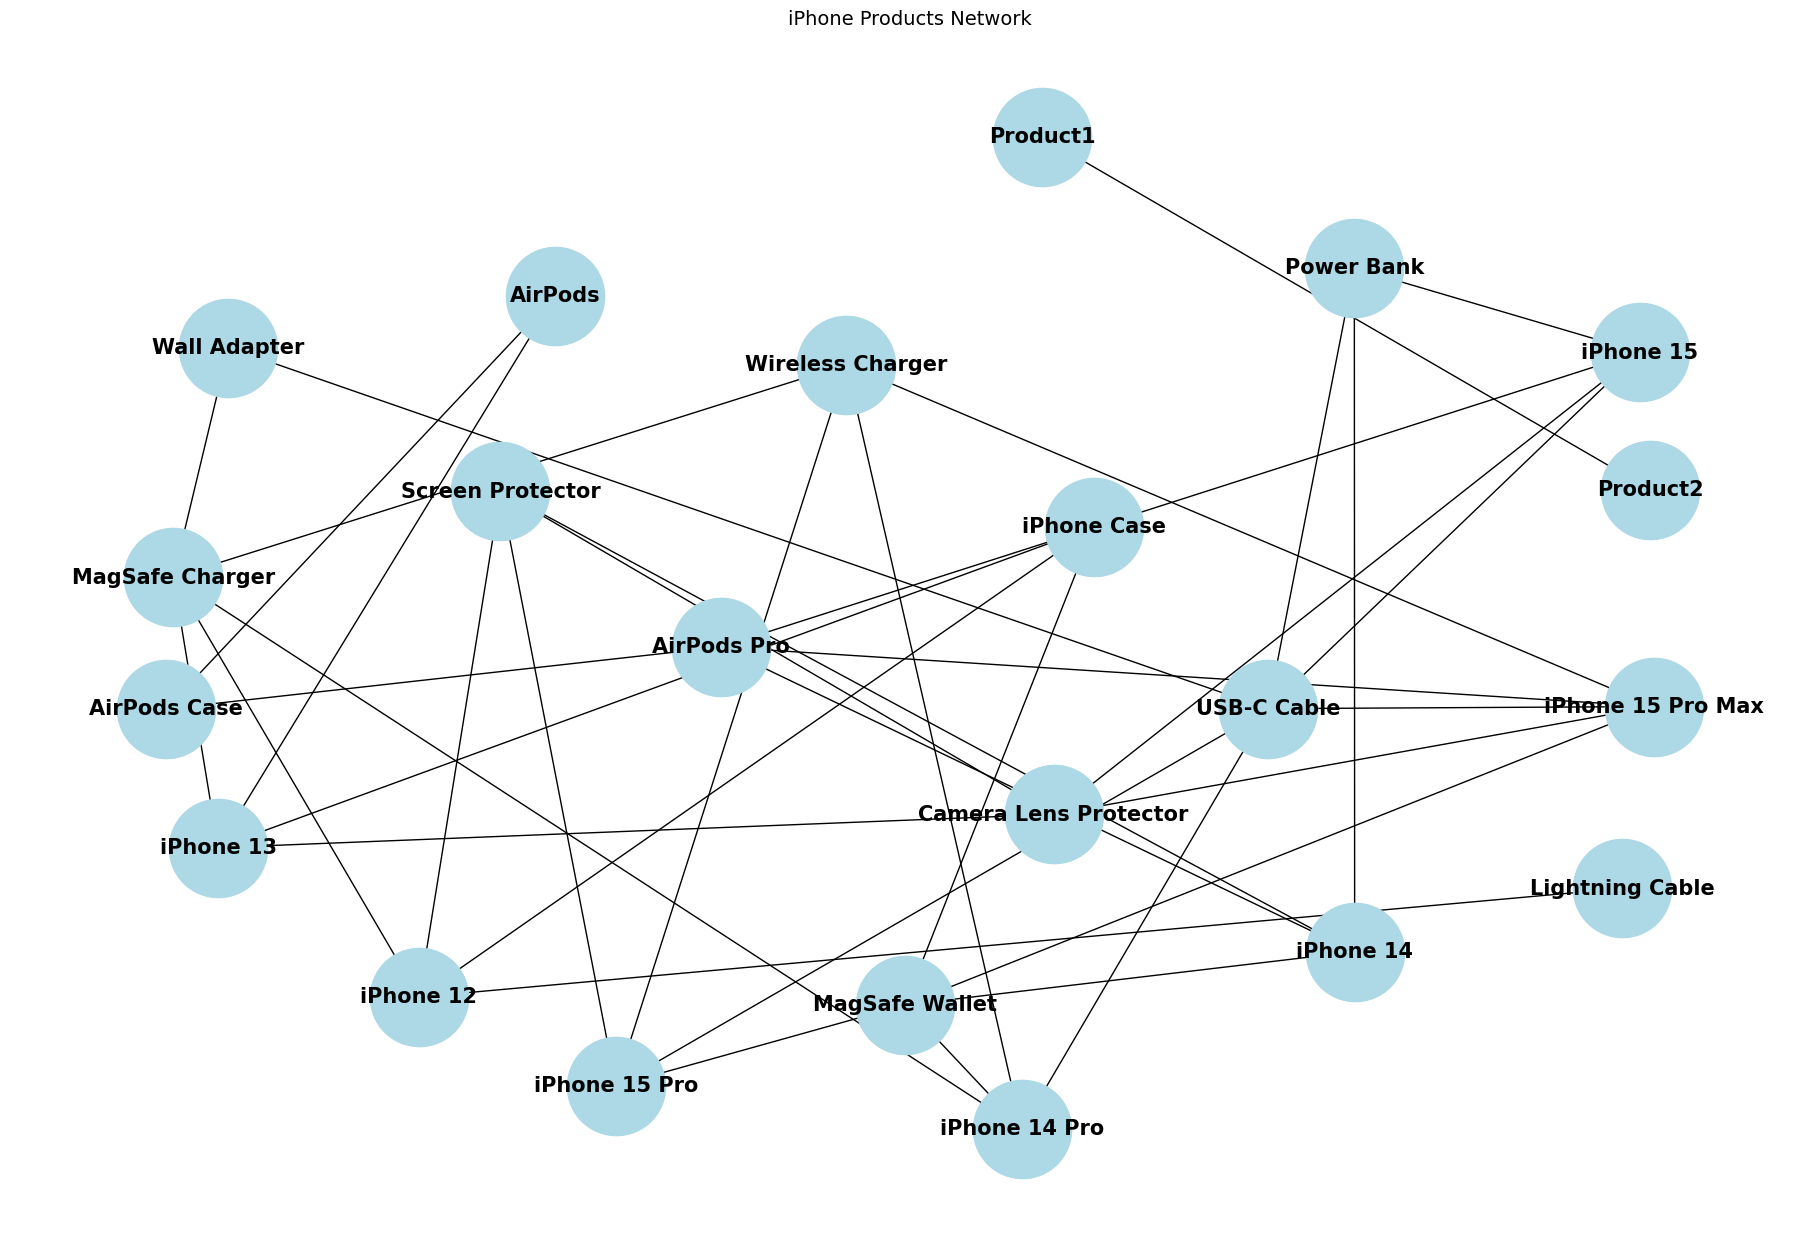

Most connected product for each iPhone model:

iPhone 12 ➜ MagSafe Charger (connections: 5)
iPhone Case ➜ MagSafe Wallet (connections: 5)
iPhone 13 ➜ MagSafe Charger (connections: 5)
iPhone 14 ➜ MagSafe Wallet (connections: 5)
iPhone 14 Pro ➜ USB-C Cable (connections: 6)
iPhone 15 ➜ USB-C Cable (connections: 6)
iPhone 15 Pro ➜ USB-C Cable (connections: 6)
iPhone 15 Pro Max ➜ USB-C Cable (connections: 6)


In [ ]:
# -*- coding: utf-8 -*-
"""phase 3.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1Upm5muk00BqyyxqO_Wd2Xr5YA78uAGvu
"""

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('modern_iphone_relations.csv', header=None, names=['Product1', 'Product2'])


G = nx.Graph()
G.add_edges_from(df.values)

plt.figure(figsize=(18, 12))
pos = nx.spring_layout(G, seed=42,k = 2, scale = 3)
nx.draw(G, pos, with_labels=True, node_size=5000, node_color='lightblue', font_size=15,font_weight ='bold')
plt.title("iPhone Products Network", fontsize=14)
plt.show()


iphone_models = [node for node in G.nodes if "iPhone" in node]

print("Most connected product for each iPhone model:\n")
for model in iphone_models:
    neighbors = list(G.neighbors(model))
    if not neighbors:
        print(f"{model}: No related products.")
        continue

    most_related = sorted(neighbors, key=lambda x: G.degree(x), reverse=True)[0]
    print(f"{model} ➜ {most_related} (connections: {G.degree(most_related)})")



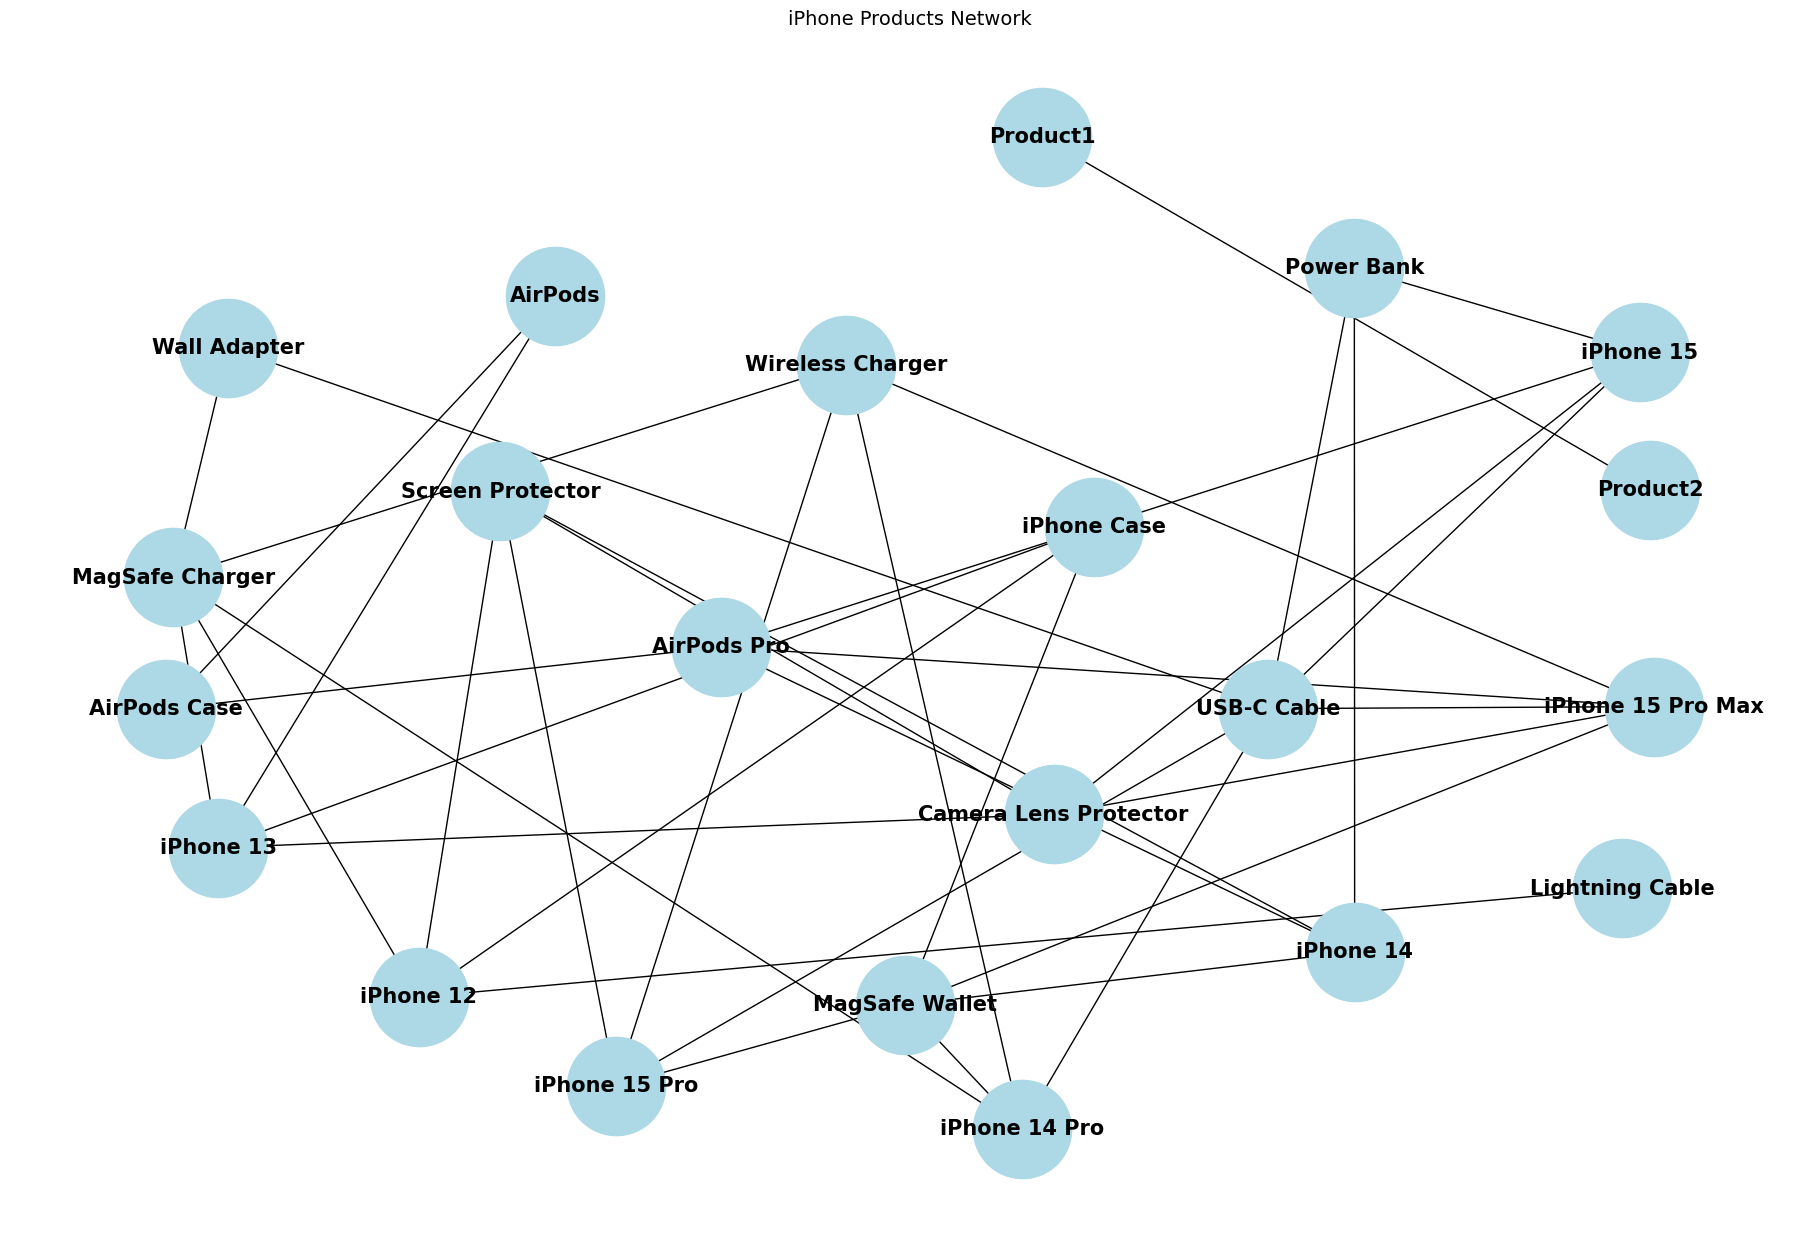

Most connected product for each iPhone model:

iPhone 12 ➜ MagSafe Charger (connections: 5)
iPhone Case ➜ MagSafe Wallet (connections: 5)
iPhone 13 ➜ MagSafe Charger (connections: 5)
iPhone 14 ➜ MagSafe Wallet (connections: 5)
iPhone 14 Pro ➜ USB-C Cable (connections: 6)
iPhone 15 ➜ USB-C Cable (connections: 6)
iPhone 15 Pro ➜ USB-C Cable (connections: 6)
iPhone 15 Pro Max ➜ USB-C Cable (connections: 6)


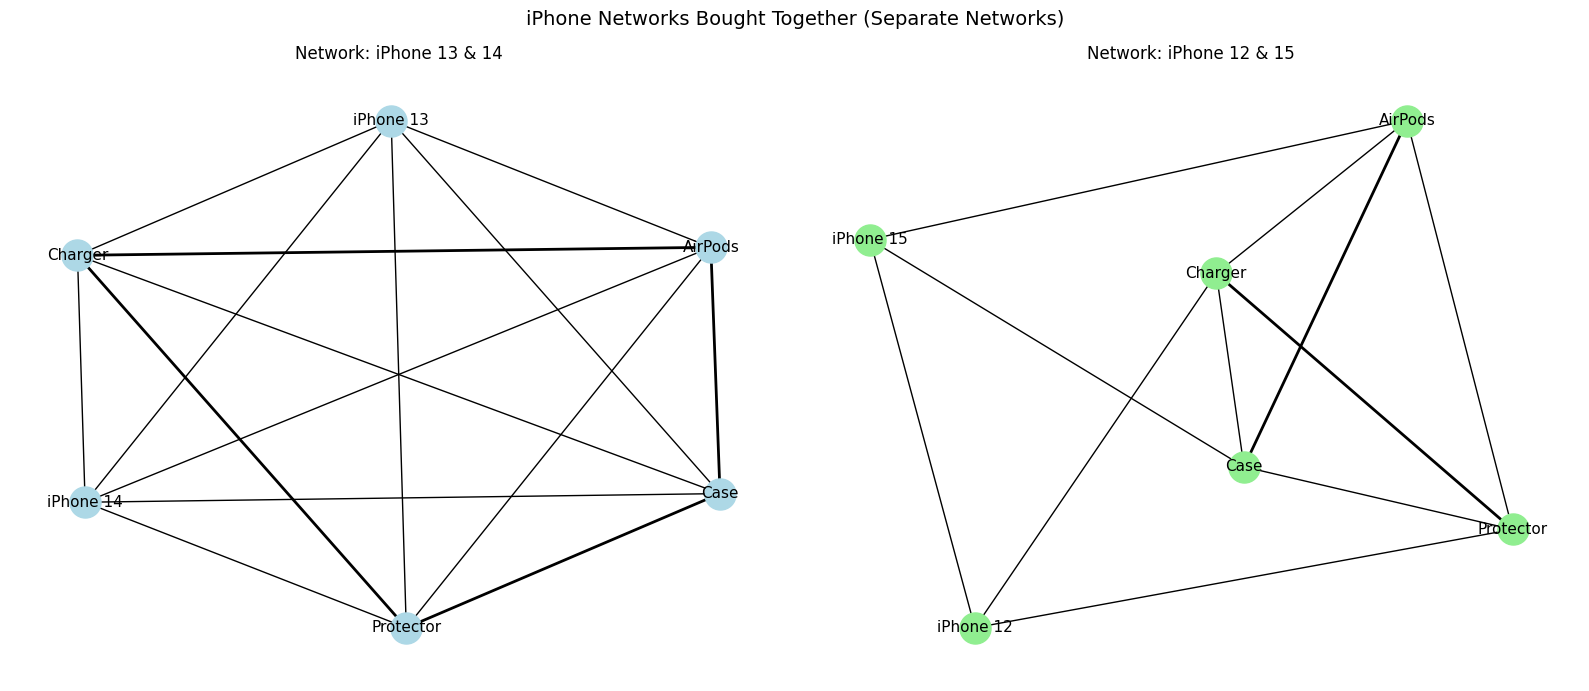

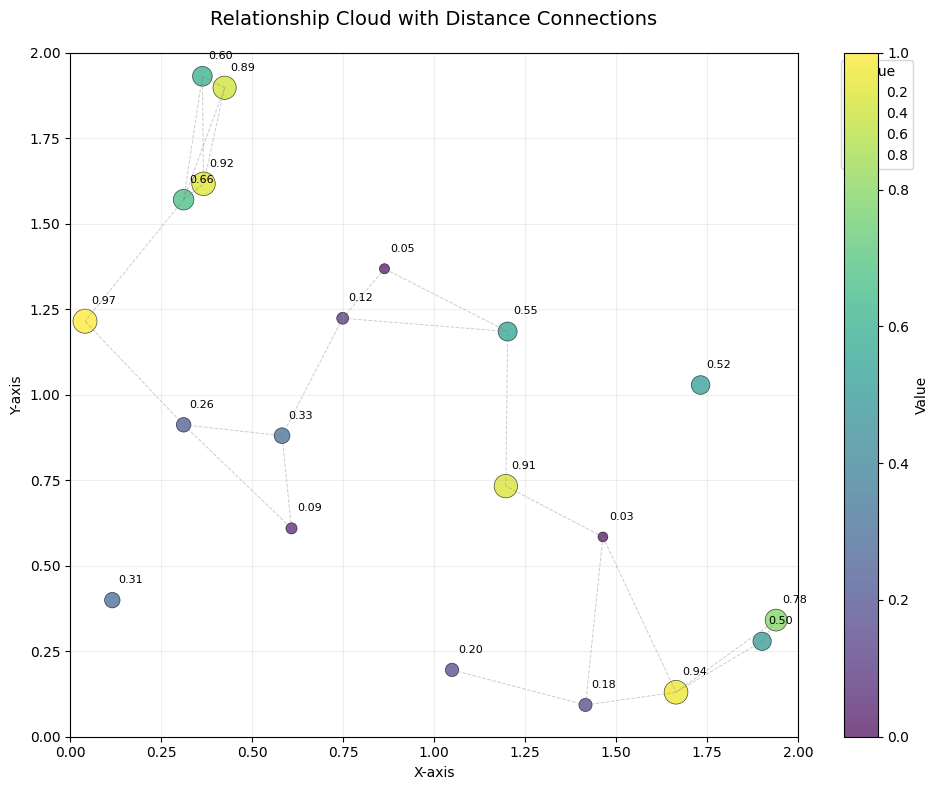

In [ ]:
# -*- coding: utf-8 -*-
"""phase 222.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1Upm5muk00BqyyxqO_Wd2Xr5YA78uAGvu
"""

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('modern_iphone_relations.csv', header=None, names=['Product1', 'Product2'])


G = nx.Graph()
G.add_edges_from(df.values)

plt.figure(figsize=(18, 12))
pos = nx.spring_layout(G, seed=42,k = 2, scale = 3)
nx.draw(G, pos, with_labels=True, node_size=5000, node_color='lightblue', font_size=15,font_weight ='bold')
plt.title("iPhone Products Network", fontsize=14)
plt.show()


iphone_models = [node for node in G.nodes if "iPhone" in node]

print("Most connected product for each iPhone model:\n")
for model in iphone_models:
    neighbors = list(G.neighbors(model))
    if not neighbors:
        print(f"{model}: No related products.")
        continue

    most_related = sorted(neighbors, key=lambda x: G.degree(x), reverse=True)[0]
    print(f"{model} ➜ {most_related} (connections: {G.degree(most_related)})")

import networkx as nx
import matplotlib.pyplot as plt

graph1 = nx.Graph()


shared_labels = {
    3: "Case",
    4: "Protector",
    5: "AirPods",
    6: "Charger"
}


orders1 = [
    [1, 3, 4],
    [2, 3, 5],
    [1, 5, 6],
    [2, 4, 6],
    [1, 2],
    [3, 4, 5, 6]
]


for order in orders1:
    for i in range(len(order)):
        for j in range(i+1, len(order)):
            a, b = order[i], order[j]
            if graph1.has_edge(a, b):
                graph1[a][b]['count'] += 1
            else:
                graph1.add_edge(a, b, count=1)

labels1 = {
    1: "iPhone 13",
    2: "iPhone 14",
    **shared_labels
}


graph2 = nx.Graph()


orders2 = [
    [7, 3, 5],
    [8, 4, 6],
    [7, 8],
    [3, 4, 5, 6]
]


for order in orders2:
    for i in range(len(order)):
        for j in range(i+1, len(order)):
            a, b = order[i], order[j]
            if graph2.has_edge(a, b):
                graph2[a][b]['count'] += 1
            else:
                graph2.add_edge(a, b, count=1)

labels2 = {
    7: "iPhone 15",
    8: "iPhone 12",
    **shared_labels
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))


pos1 = nx.spring_layout(graph1, seed=42)
nx.draw(graph1, pos1, ax=axes[0], with_labels=False, node_size=500, node_color='lightblue', width=[graph1[u][v]['count'] for u, v in graph1.edges()])
nx.draw_networkx_labels(graph1, pos1, labels=labels1, ax=axes[0], font_size=11)
axes[0].set_title("Network: iPhone 13 & 14")
axes[0].axis('off')


pos2 = nx.spring_layout(graph2, seed=99)
nx.draw(graph2, pos2, ax=axes[1], with_labels=False, node_size=500, node_color='lightgreen', width=[graph2[u][v]['count'] for u, v in graph2.edges()])
nx.draw_networkx_labels(graph2, pos2, labels=labels2, ax=axes[1], font_size=11)
axes[1].set_title("Network: iPhone 12 & 15")
axes[1].axis('off')

plt.suptitle("iPhone Networks Bought Together (Separate Networks)", fontsize=14)
plt.tight_layout()
plt.show()

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


np.random.seed(42)
n_points = 20
x = np.random.uniform(0, 2, n_points)
y = np.random.uniform(0, 2, n_points)
values = np.random.uniform(0, 1, n_points)


df = pd.DataFrame({'X': x, 'Y': y, 'Value': values})


plt.figure(figsize=(10, 8))


scatter = sns.scatterplot(
    data=df,
    x='X',
    y='Y',
    size='Value',
    hue='Value',
    sizes=(50, 300),
    palette='viridis',
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)


for i in range(len(df)):
    plt.text(
        x=df.X[i]+0.05,
        y=df.Y[i]+0.05,
        s=f"{df.Value[i]:.2f}",
        fontsize=8,
        ha='center'
    )


threshold = 0.5
for i in range(len(df)):
    for j in range(i+1, len(df)):
        distance = np.sqrt((df.X[i]-df.X[j])**2 + (df.Y[i]-df.Y[j])**2)
        if distance < threshold:
            plt.plot(
                [df.X[i], df.X[j]],
                [df.Y[i], df.Y[j]],
                color='gray',
                linestyle='--',
                alpha=0.4,
                linewidth=0.7
            )


plt.title('Relationship Cloud with Distance Connections', pad=20, fontsize=14)
plt.xlabel('X-axis', fontsize=10)
plt.ylabel('Y-axis', fontsize=10)
plt.grid(True, alpha=0.2)
plt.xlim(0, 2)
plt.ylim(0, 2)


plt.colorbar(scatter.collections[0], label='Value')
plt.legend(title='Value', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Main Data:
          Product  Price         Region  \
0       iPhone 12    699  North America   
1       iPhone 12    720         Europe   
2       iPhone 12    710           Asia   
3       iPhone 13    799  North America   
4       iPhone 13    820         Europe   
5       iPhone 13    810           Asia   
6       iPhone 14    899  North America   
7       iPhone 14    920         Europe   
8       iPhone 14    910           Asia   
9       iPhone 15    999  North America   
10      iPhone 15   1020         Europe   
11      iPhone 15   1010           Asia   
12  iPhone 15 Pro   1199  North America   
13  iPhone 15 Pro   1220         Europe   
14  iPhone 15 Pro   1210           Asia   

                                          Description  \
0   The iPhone 12 and iPhone 12 Mini (stylized and...   
1   The iPhone 12 and iPhone 12 Mini (stylized and...   
2   The iPhone 12 and iPhone 12 Mini (stylized and...   
3   The iPhone 13 and iPhone 13 Mini (stylized as ...   
4   The iPhone 

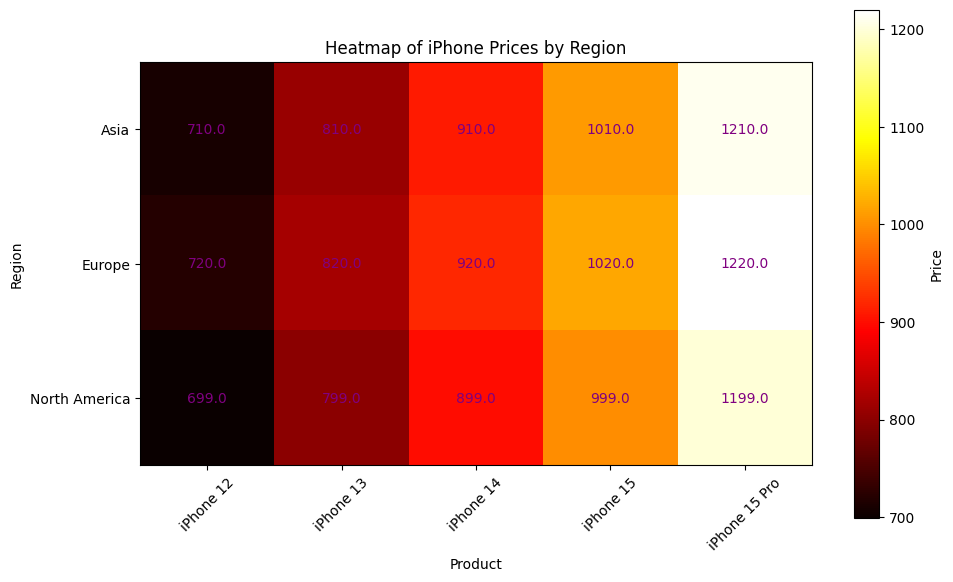

In [ ]:
#Load the main data from products_data.csv and  Create the Heatmap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv("products_data.csv")
print("Main Data:")
print(df)


pivot_table = df.pivot_table(index="Region", columns="Product", values="Price", aggfunc="mean") #aggfunc="mean"  لو حاجتين لهم نفس السعر بتجيب متوسط السعر بتاعهم
print("Pivot Table for Heatmap:")
print(pivot_table)


plt.figure(figsize=(10, 6))
heatmap_data = pivot_table.values
im = plt.imshow(heatmap_data, cmap="hot", interpolation="nearest") # interpolation="nearest"  مش بتخلط الالوان بتخليها مربعات واضحة
plt.colorbar(im, label="Price")
plt.xticks(np.arange(len(pivot_table.columns)), pivot_table.columns, rotation=45)
plt.yticks(np.arange(len(pivot_table.index)), pivot_table.index)
for i in range(len(pivot_table.index)):
    for j in range(len(pivot_table.columns)):
        plt.text(j, i, f"{heatmap_data[i, j]:.1f}", ha="center", va="center", color="purple")
plt.title("Heatmap of iPhone Prices by Region")
plt.xlabel("Product")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

In [ ]:
#3D cloud and UI
!pip install plotly scikit-learn

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "colab"

data = {
    "Product": ["iPhone 12", "iPhone 12", "iPhone 12", "iPhone 13", "iPhone 13", "iPhone 13", "iPhone 14", "iPhone 14", "iPhone 14",
                "iPhone 15", "iPhone 15", "iPhone 15", "iPhone 15 Pro", "iPhone 15 Pro", "iPhone 15 Pro"],
    "Price": [699, 720, 710, 799, 820, 810, 899, 920, 910, 999, 1020, 1010, 1199, 1220, 1210],
    "Region": ["North America", "Europe", "Asia", "North America", "Europe", "Asia", "North America", "Europe", "Asia",
               "North America", "Europe", "Asia", "North America", "Europe", "Asia"]
}

products_df = pd.DataFrame(data)

np.random.seed(42)
products_df['Rating'] = np.random.uniform(3.5, 5.0, size=len(products_df))
products_df['Reviews'] = np.random.randint(100, 1000, size=len(products_df))

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(products_df[['Price', 'Rating', 'Reviews']].values)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)
products_df['Cluster'] = clusters

fig = go.Figure()

scatter = go.Scatter3d(
    x=products_df['Price'],
    y=products_df['Rating'],
    z=products_df['Reviews'],
    mode='markers',
    marker=dict(
        size=8,
        color=products_df['Cluster'],
        colorscale='Hot',
        opacity=0.8,
        line=dict(width=0.5, color='DarkSlateGrey'),
        showscale=True,
        colorbar=dict(title="Cluster")
    ),
    text=products_df.apply(lambda row: f"Product: {row['Product']}<br>Price: ${row['Price']}<br>Rating: {row['Rating']:.1f}<br>Reviews: {row['Reviews']}<br>Region: {row['Region']}<br>Cluster: {row['Cluster']}", axis=1),
    hoverinfo='text'
)

fig.add_trace(scatter)

fig.update_layout(
    title="3D Point Cloud Analysis of iPhone Products<br><sub>Use the dropdown menus: Region (left), Price (middle), or Colorscale (right) to filter</sub>",
    scene=dict(
        xaxis_title="Price ($)",
        yaxis_title="Rating",
        zaxis_title="Number of Reviews"
    ),
    width=600,
    height=500,
    margin=dict(l=0, r=0, b=0, t=40),
    autosize=True,
    updatemenus=[
        dict(
            buttons=[
                dict(label="All Regions", method="update", args=[{
                    "x": [products_df['Price']],
                    "y": [products_df['Rating']],
                    "z": [products_df['Reviews']],
                    "text": [products_df.apply(lambda row: f"Product: {row['Product']}<br>Price: ${row['Price']}<br>Rating: {row['Rating']:.1f}<br>Reviews: {row['Reviews']}<br>Region: {row['Region']}<br>Cluster: {row['Cluster']}", axis=1)],
                    "marker.color": [products_df['Cluster']]
                }]),
                dict(label="North America", method="update", args=[{
                    "x": [products_df[products_df['Region'] == "North America"]['Price']],
                    "y": [products_df[products_df['Region'] == "North America"]['Rating']],
                    "z": [products_df[products_df['Region'] == "North America"]['Reviews']],
                    "text": [products_df[products_df['Region'] == "North America"].apply(lambda row: f"Product: {row['Product']}<br>Price: ${row['Price']}<br>Rating: {row['Rating']:.1f}<br>Reviews: {row['Reviews']}<br>Region: {row['Region']}<br>Cluster: {row['Cluster']}", axis=1)],
                    "marker.color": [products_df[products_df['Region'] == "North America"]['Cluster']]
                }]),
                dict(label="Europe", method="update", args=[{
                    "x": [products_df[products_df['Region'] == "Europe"]['Price']],
                    "y": [products_df[products_df['Region'] == "Europe"]['Rating']],
                    "z": [products_df[products_df['Region'] == "Europe"]['Reviews']],
                    "text": [products_df[products_df['Region'] == "Europe"].apply(lambda row: f"Product: {row['Product']}<br>Price: ${row['Price']}<br>Rating: {row['Rating']:.1f}<br>Reviews: {row['Reviews']}<br>Region: {row['Region']}<br>Cluster: {row['Cluster']}", axis=1)],
                    "marker.color": [products_df[products_df['Region'] == "Europe"]['Cluster']]
                }]),
                dict(label="Asia", method="update", args=[{
                    "x": [products_df[products_df['Region'] == "Asia"]['Price']],
                    "y": [products_df[products_df['Region'] == "Asia"]['Rating']],
                    "z": [products_df[products_df['Region'] == "Asia"]['Reviews']],
                    "text": [products_df[products_df['Region'] == "Asia"].apply(lambda row: f"Product: {row['Product']}<br>Price: ${row['Price']}<br>Rating: {row['Rating']:.1f}<br>Reviews: {row['Reviews']}<br>Region: {row['Region']}<br>Cluster: {row['Cluster']}", axis=1)],
                    "marker.color": [products_df[products_df['Region'] == "Asia"]['Cluster']]
                }])
            ],
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.11,
            xanchor="left",
            y=1.05,
            yanchor="top"
        ),
        dict(
            buttons=[
                dict(label="All Prices", method="update", args=[{
                    "x": [products_df['Price']],
                    "y": [products_df['Rating']],
                    "z": [products_df['Reviews']],
                    "text": [products_df.apply(lambda row: f"Product: {row['Product']}<br>Price: ${row['Price']}<br>Rating: {row['Rating']:.1f}<br>Reviews: {row['Reviews']}<br>Region: {row['Region']}<br>Cluster: {row['Cluster']}", axis=1)],
                    "marker.color": [products_df['Cluster']]
                }]),
                dict(label="Price < $800", method="update", args=[{
                    "x": [products_df[products_df['Price'] < 800]['Price']],
                    "y": [products_df[products_df['Price'] < 800]['Rating']],
                    "z": [products_df[products_df['Price'] < 800]['Reviews']],
                    "text": [products_df[products_df['Price'] < 800].apply(lambda row: f"Product: {row['Product']}<br>Price: ${row['Price']}<br>Rating: {row['Rating']:.1f}<br>Reviews: {row['Reviews']}<br>Region: {row['Region']}<br>Cluster: {row['Cluster']}", axis=1)],
                    "marker.color": [products_df[products_df['Price'] < 800]['Cluster']]
                }]),
                dict(label="Price $800-$1000", method="update", args=[{
                    "x": [products_df[(products_df['Price'] >= 800) & (products_df['Price'] <= 1000)]['Price']],
                    "y": [products_df[(products_df['Price'] >= 800) & (products_df['Price'] <= 1000)]['Rating']],
                    "z": [products_df[(products_df['Price'] >= 800) & (products_df['Price'] <= 1000)]['Reviews']],
                    "text": [products_df[(products_df['Price'] >= 800) & (products_df['Price'] <= 1000)].apply(lambda row: f"Product: {row['Product']}<br>Price: ${row['Price']}<br>Rating: {row['Rating']:.1f}<br>Reviews: {row['Reviews']}<br>Region: {row['Region']}<br>Cluster: {row['Cluster']}", axis=1)],
                    "marker.color": [products_df[(products_df['Price'] >= 800) & (products_df['Price'] <= 1000)]['Cluster']]
                }]),
                dict(label="Price > $1000", method="update", args=[{
                    "x": [products_df[products_df['Price'] > 1000]['Price']],
                    "y": [products_df[products_df['Price'] > 1000]['Rating']],
                    "z": [products_df[products_df['Price'] > 1000]['Reviews']],
                    "text": [products_df[products_df['Price'] > 1000].apply(lambda row: f"Product: {row['Product']}<br>Price: ${row['Price']}<br>Rating: {row['Rating']:.1f}<br>Reviews: {row['Reviews']}<br>Region: {row['Region']}<br>Cluster: {row['Cluster']}", axis=1)],
                    "marker.color": [products_df[products_df['Price'] > 1000]['Cluster']]
                }])
            ],
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.3,
            xanchor="left",
            y=1.05,
            yanchor="top"
        ),
        dict(
            buttons=[
                dict(label="Hot", method="update", args=[{"marker.colorscale": "Hot"}]),
                dict(label="Viridis", method="update", args=[{"marker.colorscale": "Viridis"}]),
                dict(label="Plasma", method="update", args=[{"marker.colorscale": "Plasma"}]),
                dict(label="Jet", method="update", args=[{"marker.colorscale": "Jet"}])
            ],
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.5,
            xanchor="left",
            y=1.05,
            yanchor="top"
        ),
    ]
)

fig.show()

Statistics: {'Price Mean': np.float64(2579.6666666666665), 'Price Median': 3100.0, 'Rating Mean': np.float64(4.62), 'Rating Median': 4.6}


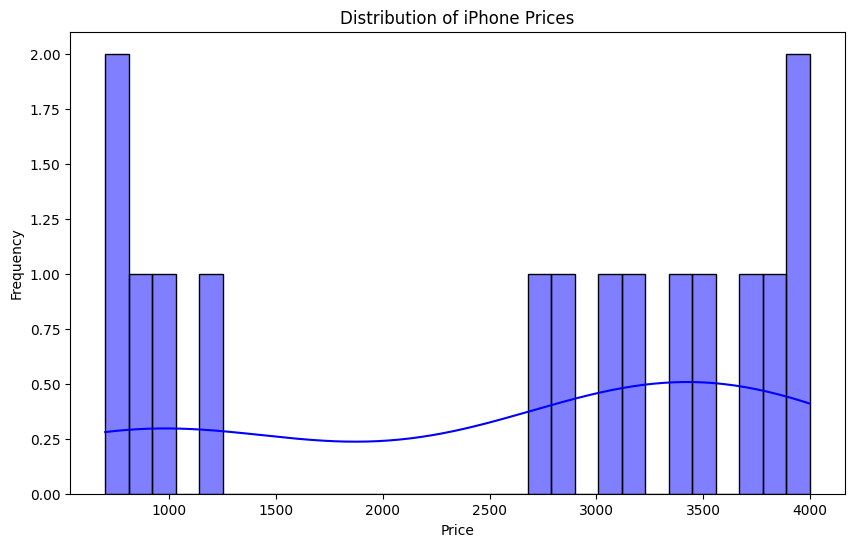

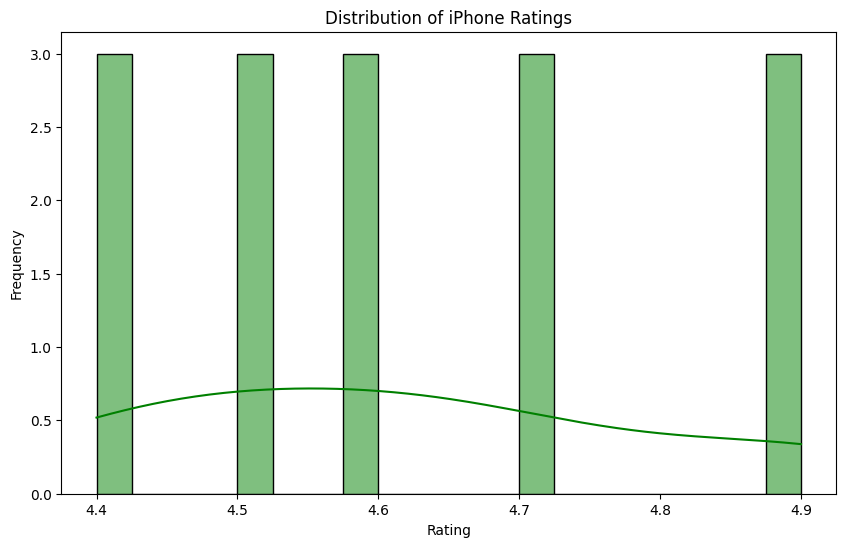

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

def load_data(file_path="iphone_data.csv"):
    if not os.path.exists(file_path):
        print(f"Error: File '{file_path}' not found in the current directory: {os.getcwd()}")
        return None
    try:
        df = pd.read_csv(file_path)
        return df
    except Exception as e:
        print(f"Error reading file: {e}")
        return None

df = load_data("iphone_data.csv")
if df is None:
    raise SystemExit("Cannot proceed without data.")

df = df.dropna(subset=['price', 'rating', 'review_count'])
df['price'] = df['price'].apply(pd.to_numeric, errors='coerce')
df['rating'] = df['rating'].apply(pd.to_numeric, errors='coerce')
df['review_count'] = df['review_count'].apply(pd.to_numeric, errors='coerce')

df['rating_category'] = pd.cut(df['rating'], bins=[0, 2, 3, 4, 5], labels=['Poor', 'Fair', 'Good', 'Excellent'])

price_mean = df['price'].mean()
price_median = df['price'].median()
rating_mean = df['rating'].mean()
rating_median = df['rating'].median()

statistics = {
    "Price Mean": price_mean,
    "Price Median": price_median,
    "Rating Mean": rating_mean,
    "Rating Median": rating_median
}
print("Statistics:", statistics)

plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=30, kde=True, color='blue')
plt.title('Distribution of iPhone Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['rating'], bins=20, kde=True, color='green')
plt.title('Distribution of iPhone Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()